In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:

all_records = []
import requests
for page in range(1, 6):
    url=f"https://api.coingecko.com/api/v3/coins/markets?vs_currency=inr&per_page=250&order=market_cap_desc&page={page}&sparkline=False"
    response=requests.get(url)
    if response.status_code==200:
        data=response.json()
        all_records.extend(data)
    
    
    
records=[]
for i in all_records:
    records.append(dict(id=i["id"],
                        symbol=i["symbol"],
                        name=i["name"],
                        current_price=i["current_price"],
                        market_cap=i["market_cap"],
                        market_cap_rank=i["market_cap_rank"],
                        total_volume=i["total_volume"],
                        circulating_supply=i["circulating_supply"],
                        total_supply=i["total_supply"],
                        ath=i["ath"],
                        atl=i["atl"],
                        last_updated=i["last_updated"]))
print(records)
     

[{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'current_price': 6332091, 'market_cap': 126553713760697, 'market_cap_rank': 1, 'total_volume': 3542403362935, 'circulating_supply': 19989353.0, 'total_supply': 19989353.0, 'ath': 11187013, 'atl': 3993.42, 'last_updated': '2026-02-14T22:36:21.291Z'}, {'id': 'ethereum', 'symbol': 'eth', 'name': 'Ethereum', 'current_price': 189179, 'market_cap': 22813848553856, 'market_cap_rank': 2, 'total_volume': 1457537277951, 'circulating_supply': 120692467.6142904, 'total_supply': 120692467.6142904, 'ath': 431946, 'atl': 28.13, 'last_updated': '2026-02-14T22:36:21.497Z'}, {'id': 'tether', 'symbol': 'usdt', 'name': 'Tether', 'current_price': 90.52, 'market_cap': 16638662852594, 'market_cap_rank': 3, 'total_volume': 5728158610639, 'circulating_supply': 183816960128.6833, 'total_supply': 189283897370.0162, 'ath': 105.52, 'atl': 36.86, 'last_updated': '2026-02-14T22:36:33.587Z'}, {'id': 'ripple', 'symbol': 'xrp', 'name': 'XRP', 'current_price': 135.6

In [3]:
import pandas as pd
coins_df=pd.DataFrame(records)
coins_df

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,circulating_supply,total_supply,ath,atl,last_updated
0,bitcoin,btc,Bitcoin,6.332091e+06,126553713760697,1,3.542403e+12,1.998935e+07,1.998935e+07,11187013.00,3993.420000,2026-02-14T22:36:21.291Z
1,ethereum,eth,Ethereum,1.891790e+05,22813848553856,2,1.457537e+12,1.206925e+08,1.206925e+08,431946.00,28.130000,2026-02-14T22:36:21.497Z
2,tether,usdt,Tether,9.052000e+01,16638662852594,3,5.728159e+12,1.838170e+11,1.892839e+11,105.52,36.860000,2026-02-14T22:36:33.587Z
3,ripple,xrp,XRP,1.356700e+02,8259400944849,4,2.119723e+11,6.091732e+10,9.998572e+10,313.99,0.159343,2026-02-14T22:36:33.415Z
4,binancecoin,bnb,BNB,5.722900e+04,7798698414137,5,7.350247e+10,1.363593e+08,1.363593e+08,121422.00,2.580000,2026-02-14T22:36:21.273Z
...,...,...,...,...,...,...,...,...,...,...,...,...
745,destra-network,dsync,Destra Network,2.170000e+00,2165898351,746,1.850870e+08,9.975054e+08,9.975054e+08,46.98,0.931607,2026-02-14T22:36:37.237Z
746,gigachad-2,giga,Gigachad,2.255060e-01,2164839161,747,1.495658e+08,9.604137e+09,9.604137e+09,8.16,0.001034,2026-02-14T22:36:37.341Z
747,faith-tribe,ftrb,Faith Tribe,6.727100e-01,2163829701,748,4.023260e+07,3.229511e+09,5.000000e+09,5.36,0.145084,2026-02-14T22:36:37.115Z
748,global-commercial-business,gcb,Global Commercial Business,1.780000e+00,2142737409,749,1.821940e+05,1.201845e+09,1.201845e+09,28.60,1.690000,2026-02-14T22:36:37.193Z


In [4]:
coins_df['timestamp'] = pd.to_datetime(coins_df['last_updated'])
print (coins_df)

                             id symbol                        name  \
0                       bitcoin    btc                     Bitcoin   
1                      ethereum    eth                    Ethereum   
2                        tether   usdt                      Tether   
3                        ripple    xrp                         XRP   
4                   binancecoin    bnb                         BNB   
..                          ...    ...                         ...   
745              destra-network  dsync              Destra Network   
746                  gigachad-2   giga                    Gigachad   
747                 faith-tribe   ftrb                 Faith Tribe   
748  global-commercial-business    gcb  Global Commercial Business   
749                   chromaway    chr                     Chromia   

     current_price       market_cap  market_cap_rank  total_volume  \
0     6.332091e+06  126553713760697                1  3.542403e+12   
1     1.891790e+05 

In [5]:
coins_df['last_updated_date'] = coins_df['timestamp'].dt.date
print(coins_df)

                             id symbol                        name  \
0                       bitcoin    btc                     Bitcoin   
1                      ethereum    eth                    Ethereum   
2                        tether   usdt                      Tether   
3                        ripple    xrp                         XRP   
4                   binancecoin    bnb                         BNB   
..                          ...    ...                         ...   
745              destra-network  dsync              Destra Network   
746                  gigachad-2   giga                    Gigachad   
747                 faith-tribe   ftrb                 Faith Tribe   
748  global-commercial-business    gcb  Global Commercial Business   
749                   chromaway    chr                     Chromia   

     current_price       market_cap  market_cap_rank  total_volume  \
0     6.332091e+06  126553713760697                1  3.542403e+12   
1     1.891790e+05 

In [6]:
coins_df['last_updated'] = pd.to_datetime(coins_df['last_updated']).dt.date
print(coins_df)

                             id symbol                        name  \
0                       bitcoin    btc                     Bitcoin   
1                      ethereum    eth                    Ethereum   
2                        tether   usdt                      Tether   
3                        ripple    xrp                         XRP   
4                   binancecoin    bnb                         BNB   
..                          ...    ...                         ...   
745              destra-network  dsync              Destra Network   
746                  gigachad-2   giga                    Gigachad   
747                 faith-tribe   ftrb                 Faith Tribe   
748  global-commercial-business    gcb  Global Commercial Business   
749                   chromaway    chr                     Chromia   

     current_price       market_cap  market_cap_rank  total_volume  \
0     6.332091e+06  126553713760697                1  3.542403e+12   
1     1.891790e+05 

In [7]:
coins_df.to_csv("coins_data.csv", index=False)

In [8]:
top5_coins = coins_df[coins_df['market_cap_rank'] <= 5]
top5_coins

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,circulating_supply,total_supply,ath,atl,last_updated,timestamp,last_updated_date
0,bitcoin,btc,Bitcoin,6332091.00,126553713760697,1,3.542403e+12,1.998935e+07,1.998935e+07,11187013.00,3993.420000,2026-02-14,2026-02-14 22:36:21.291000+00:00,2026-02-14
1,ethereum,eth,Ethereum,189179.00,22813848553856,2,1.457537e+12,1.206925e+08,1.206925e+08,431946.00,28.130000,2026-02-14,2026-02-14 22:36:21.497000+00:00,2026-02-14
2,tether,usdt,Tether,90.52,16638662852594,3,5.728159e+12,1.838170e+11,1.892839e+11,105.52,36.860000,2026-02-14,2026-02-14 22:36:33.587000+00:00,2026-02-14
3,ripple,xrp,XRP,135.67,8259400944849,4,2.119723e+11,6.091732e+10,9.998572e+10,313.99,0.159343,2026-02-14,2026-02-14 22:36:33.415000+00:00,2026-02-14
4,binancecoin,bnb,BNB,57229.00,7798698414137,5,7.350247e+10,1.363593e+08,1.363593e+08,121422.00,2.580000,2026-02-14,2026-02-14 22:36:21.273000+00:00,2026-02-14


In [9]:
import requests
import pandas as pd

top5_coin_ids = ["bitcoin", "ethereum", "tether", "binancecoin", "ripple"]

historical_prices = []

for coin in top5_coin_ids:
    print(f"Fetching data for: {coin}")   # debug line

    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart?vs_currency=inr&days=365"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        for ts, price in data["prices"]:
            historical_prices.append({
                "coin_id": coin,
                "date": pd.to_datetime(ts, unit="ms").date(),
                "price_inr": price
            })
    else:
        print(f"Failed for {coin}: {response.status_code}")

hist_df = pd.DataFrame(historical_prices)

hist_df.head()


Fetching data for: bitcoin
Fetching data for: ethereum
Fetching data for: tether
Fetching data for: binancecoin
Failed for binancecoin: 429
Fetching data for: ripple
Failed for ripple: 429


,coin_id,date,price_inr
0,bitcoin,2025-02-15,8.449166e+06
1,bitcoin,2025-02-16,8.452534e+06
2,bitcoin,2025-02-17,8.331281e+06
3,bitcoin,2025-02-18,8.318633e+06
4,bitcoin,2025-02-19,8.297395e+06


In [10]:
hist_df['coin_id'].unique()


array(['bitcoin', 'ethereum', 'tether'], dtype=object)

In [11]:

merged_df = hist_df.merge(
    top5_coins,
    left_on='coin_id',
    right_on='id',
    how='left'
)
print(merged_df)


      coin_id        date     price_inr       id symbol     name  \
0     bitcoin  2025-02-15  8.449166e+06  bitcoin    btc  Bitcoin   
1     bitcoin  2025-02-16  8.452534e+06  bitcoin    btc  Bitcoin   
2     bitcoin  2025-02-17  8.331281e+06  bitcoin    btc  Bitcoin   
3     bitcoin  2025-02-18  8.318633e+06  bitcoin    btc  Bitcoin   
4     bitcoin  2025-02-19  8.297395e+06  bitcoin    btc  Bitcoin   
...       ...         ...           ...      ...    ...      ...   
1093   tether  2026-02-11  9.054272e+01   tether   usdt   Tether   
1094   tether  2026-02-12  9.068274e+01   tether   usdt   Tether   
1095   tether  2026-02-13  9.050516e+01   tether   usdt   Tether   
1096   tether  2026-02-14  9.051814e+01   tether   usdt   Tether   
1097   tether  2026-02-14  9.051913e+01   tether   usdt   Tether   

      current_price       market_cap  market_cap_rank  total_volume  \
0        6332091.00  126553713760697                1  3.542403e+12   
1        6332091.00  126553713760697     

In [12]:
merged_df.to_csv("merged_data.csv", index=False)

In [13]:
import pandas as pd
oil_df=pd.read_csv("https://raw.githubusercontent.com/datasets/oil-prices/main/data/wti-daily.csv")
print(oil_df)

             Date  Price
0      1986-01-02  25.56
1      1986-01-03  26.00
2      1986-01-06  26.53
3      1986-01-07  25.85
4      1986-01-08  25.87
...           ...    ...
10090  2026-02-03  62.62
10091  2026-02-04  64.56
10092  2026-02-05  62.90
10093  2026-02-06  63.77
10094  2026-02-09  64.53

[10095 rows x 2 columns]


In [17]:
oil_df['Date'] = pd.to_datetime(oil_df['Date'])


In [18]:
five_years= pd.Timestamp.today() - pd.DateOffset(years=5)

oil_5y = oil_df[oil_df['Date'] >= five_years]

oil_5y



,Date,Price
8850,2021-02-16,60.07
8851,2021-02-17,61.09
8852,2021-02-18,60.40
8853,2021-02-19,59.12
8854,2021-02-22,61.67
...,...,...
10090,2026-02-03,62.62
10091,2026-02-04,64.56
10092,2026-02-05,62.90
10093,2026-02-06,63.77


In [19]:
import pandas as pd

usd_to_inr = 90.56

oil_5y["price_inr"] = oil_5y["Price"] * usd_to_inr

C:\Users\brind\AppData\Local\Temp\ipykernel_9400\1267130265.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oil_5y["price_inr"] = oil_5y["Price"] * usd_to_inr


In [20]:
oil_5y = oil_5y.sort_values('Date')
oil_5y


,Date,Price,price_inr
8850,2021-02-16,60.07,5439.9392
8851,2021-02-17,61.09,5532.3104
8852,2021-02-18,60.40,5469.8240
8853,2021-02-19,59.12,5353.9072
8854,2021-02-22,61.67,5584.8352
...,...,...,...
10090,2026-02-03,62.62,5670.8672
10091,2026-02-04,64.56,5846.5536
10092,2026-02-05,62.90,5696.2240
10093,2026-02-06,63.77,5775.0112


In [21]:
oil_5y.to_csv("oil5y_data.csv", index=False)

In [22]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [44]:
import yfinance as yf
import pandas as pd

tickers=["^GSPC","^IXIC","^NSEI"]
start_date="2020-01-01"
end_date="2026-02-01"
stocks_df=yf.download(tickers,start=start_date,end=end_date,group_by="tickers")
stocks_df

[*********************100%***********************]  3 of 3 completed


Ticker            ^GSPC                                                       \
Price              Open         High          Low        Close        Volume   
Date                                                                           
2020-01-01          NaN          NaN          NaN          NaN           NaN   
2020-01-02  3244.669922  3258.139893  3235.530029  3257.850098  3.459930e+09   
2020-01-03  3226.360107  3246.149902  3222.340088  3234.850098  3.484700e+09   
2020-01-06  3217.550049  3246.840088  3214.639893  3246.280029  3.702460e+09   
2020-01-07  3241.860107  3244.909912  3232.429932  3237.179932  3.435910e+09   
...                 ...          ...          ...          ...           ...   
2026-01-26  6923.229980  6964.660156  6921.600098  6950.229980  4.968050e+09   
2026-01-27  6965.959961  6988.819824  6958.830078  6978.600098  5.331720e+09   
2026-01-28  7002.000000  7002.279785  6963.459961  6978.029785  5.507670e+09   
2026-01-29  6977.740234  6992.839844  6870.799805  6969.009766  6.877780e+09   
2026-01-30  6947.270020  6964.089844  6893.479980  6939.029785  6.697340e+09   

Ticker             ^IXIC                                            \
Price               Open          High           Low         Close   
Date                                                                 
2020-01-01           NaN           NaN           NaN           NaN   
2020-01-02   9039.459961   9093.429688   9010.889648   9092.190430   
2020-01-03   8976.429688   9065.759766   8976.429688   9020.769531   
2020-01-06   8943.500000   9072.410156   8943.500000   9071.469727   
2020-01-07   9076.639648   9091.929688   9042.549805   9068.580078   
...                  ...           ...           ...           ...   
2026-01-26  23529.279297  23688.939453  23486.080078  23601.359375   
2026-01-27  23734.750000  23865.259766  23694.380859  23817.099609   
2026-01-28  23965.109375  23988.269531  23775.490234  23857.449219   
2026-01-29  23830.919922  23840.550781  23232.779297  23685.119141   
2026-01-30  23578.960938  23662.250000  23351.550781  23461.820312   

Ticker                           ^NSEI                              \
Price             Volume          Open          High           Low   
Date                                                                 
2020-01-01           NaN  12202.150391  12222.200195  12165.299805   
2020-01-02  2.862700e+09  12198.549805  12289.900391  12195.250000   
2020-01-03  2.586520e+09  12261.099609  12265.599609  12191.349609   
2020-01-06  2.810450e+09  12170.599609  12179.099609  11974.200195   
2020-01-07  2.381740e+09  12079.099609  12152.150391  12005.349609   
...                  ...           ...           ...           ...   
2026-01-26  7.505250e+09           NaN           NaN           NaN   
2026-01-27  8.026050e+09  25063.349609  25246.650391  24932.550781   
2026-01-28  8.151580e+09  25258.849609  25372.099609  25187.650391   
2026-01-29  8.782210e+09  25345.000000  25458.150391  25159.800781   
2026-01-30  9.255930e+09  25247.550781  25370.699219  25213.650391   

Ticker                              
Price              Close    Volume  
Date                                
2020-01-01  12182.500000  304100.0  
2020-01-02  12282.200195  407700.0  
2020-01-03  12226.650391  428800.0  
2020-01-06  11993.049805  396500.0  
2020-01-07  12052.950195  447800.0  
...                  ...       ...  
2026-01-26           NaN       NaN  
2026-01-27  25175.400391  618700.0  
2026-01-28  25342.750000  574900.0  
2026-01-29  25418.900391  582400.0  
2026-01-30  25320.650391  508400.0  

[1578 rows x 15 columns]

In [46]:
stocks_df = stocks_df.drop(columns=["level_0"], errors="ignore")


In [47]:
stocks_df

Ticker            ^GSPC                                                       \
Price              Open         High          Low        Close        Volume   
Date                                                                           
2020-01-01          NaN          NaN          NaN          NaN           NaN   
2020-01-02  3244.669922  3258.139893  3235.530029  3257.850098  3.459930e+09   
2020-01-03  3226.360107  3246.149902  3222.340088  3234.850098  3.484700e+09   
2020-01-06  3217.550049  3246.840088  3214.639893  3246.280029  3.702460e+09   
2020-01-07  3241.860107  3244.909912  3232.429932  3237.179932  3.435910e+09   
...                 ...          ...          ...          ...           ...   
2026-01-26  6923.229980  6964.660156  6921.600098  6950.229980  4.968050e+09   
2026-01-27  6965.959961  6988.819824  6958.830078  6978.600098  5.331720e+09   
2026-01-28  7002.000000  7002.279785  6963.459961  6978.029785  5.507670e+09   
2026-01-29  6977.740234  6992.839844  6870.799805  6969.009766  6.877780e+09   
2026-01-30  6947.270020  6964.089844  6893.479980  6939.029785  6.697340e+09   

Ticker             ^IXIC                                            \
Price               Open          High           Low         Close   
Date                                                                 
2020-01-01           NaN           NaN           NaN           NaN   
2020-01-02   9039.459961   9093.429688   9010.889648   9092.190430   
2020-01-03   8976.429688   9065.759766   8976.429688   9020.769531   
2020-01-06   8943.500000   9072.410156   8943.500000   9071.469727   
2020-01-07   9076.639648   9091.929688   9042.549805   9068.580078   
...                  ...           ...           ...           ...   
2026-01-26  23529.279297  23688.939453  23486.080078  23601.359375   
2026-01-27  23734.750000  23865.259766  23694.380859  23817.099609   
2026-01-28  23965.109375  23988.269531  23775.490234  23857.449219   
2026-01-29  23830.919922  23840.550781  23232.779297  23685.119141   
2026-01-30  23578.960938  23662.250000  23351.550781  23461.820312   

Ticker                           ^NSEI                              \
Price             Volume          Open          High           Low   
Date                                                                 
2020-01-01           NaN  12202.150391  12222.200195  12165.299805   
2020-01-02  2.862700e+09  12198.549805  12289.900391  12195.250000   
2020-01-03  2.586520e+09  12261.099609  12265.599609  12191.349609   
2020-01-06  2.810450e+09  12170.599609  12179.099609  11974.200195   
2020-01-07  2.381740e+09  12079.099609  12152.150391  12005.349609   
...                  ...           ...           ...           ...   
2026-01-26  7.505250e+09           NaN           NaN           NaN   
2026-01-27  8.026050e+09  25063.349609  25246.650391  24932.550781   
2026-01-28  8.151580e+09  25258.849609  25372.099609  25187.650391   
2026-01-29  8.782210e+09  25345.000000  25458.150391  25159.800781   
2026-01-30  9.255930e+09  25247.550781  25370.699219  25213.650391   

Ticker                              
Price              Close    Volume  
Date                                
2020-01-01  12182.500000  304100.0  
2020-01-02  12282.200195  407700.0  
2020-01-03  12226.650391  428800.0  
2020-01-06  11993.049805  396500.0  
2020-01-07  12052.950195  447800.0  
...                  ...       ...  
2026-01-26           NaN       NaN  
2026-01-27  25175.400391  618700.0  
2026-01-28  25342.750000  574900.0  
2026-01-29  25418.900391  582400.0  
2026-01-30  25320.650391  508400.0  

[1578 rows x 15 columns]

In [48]:
stocks_df.dropna()

Ticker            ^GSPC                                                       \
Price              Open         High          Low        Close        Volume   
Date                                                                           
2020-01-02  3244.669922  3258.139893  3235.530029  3257.850098  3.459930e+09   
2020-01-03  3226.360107  3246.149902  3222.340088  3234.850098  3.484700e+09   
2020-01-06  3217.550049  3246.840088  3214.639893  3246.280029  3.702460e+09   
2020-01-07  3241.860107  3244.909912  3232.429932  3237.179932  3.435910e+09   
2020-01-08  3238.590088  3267.070068  3236.669922  3253.050049  3.726840e+09   
...                 ...          ...          ...          ...           ...   
2026-01-23  6907.850098  6932.959961  6895.500000  6915.609863  4.871930e+09   
2026-01-27  6965.959961  6988.819824  6958.830078  6978.600098  5.331720e+09   
2026-01-28  7002.000000  7002.279785  6963.459961  6978.029785  5.507670e+09   
2026-01-29  6977.740234  6992.839844  6870.799805  6969.009766  6.877780e+09   
2026-01-30  6947.270020  6964.089844  6893.479980  6939.029785  6.697340e+09   

Ticker             ^IXIC                                            \
Price               Open          High           Low         Close   
Date                                                                 
2020-01-02   9039.459961   9093.429688   9010.889648   9092.190430   
2020-01-03   8976.429688   9065.759766   8976.429688   9020.769531   
2020-01-06   8943.500000   9072.410156   8943.500000   9071.469727   
2020-01-07   9076.639648   9091.929688   9042.549805   9068.580078   
2020-01-08   9068.030273   9168.889648   9059.379883   9129.240234   
...                  ...           ...           ...           ...   
2026-01-23  23440.919922  23610.740234  23374.259766  23501.240234   
2026-01-27  23734.750000  23865.259766  23694.380859  23817.099609   
2026-01-28  23965.109375  23988.269531  23775.490234  23857.449219   
2026-01-29  23830.919922  23840.550781  23232.779297  23685.119141   
2026-01-30  23578.960938  23662.250000  23351.550781  23461.820312   

Ticker                           ^NSEI                              \
Price             Volume          Open          High           Low   
Date                                                                 
2020-01-02  2.862700e+09  12198.549805  12289.900391  12195.250000   
2020-01-03  2.586520e+09  12261.099609  12265.599609  12191.349609   
2020-01-06  2.810450e+09  12170.599609  12179.099609  11974.200195   
2020-01-07  2.381740e+09  12079.099609  12152.150391  12005.349609   
2020-01-08  2.472620e+09  11939.099609  12044.950195  11929.599609   
...                  ...           ...           ...           ...   
2026-01-23  8.228760e+09  25344.599609  25347.949219  25025.300781   
2026-01-27  8.026050e+09  25063.349609  25246.650391  24932.550781   
2026-01-28  8.151580e+09  25258.849609  25372.099609  25187.650391   
2026-01-29  8.782210e+09  25345.000000  25458.150391  25159.800781   
2026-01-30  9.255930e+09  25247.550781  25370.699219  25213.650391   

Ticker                              
Price              Close    Volume  
Date                                
2020-01-02  12282.200195  407700.0  
2020-01-03  12226.650391  428800.0  
2020-01-06  11993.049805  396500.0  
2020-01-07  12052.950195  447800.0  
2020-01-08  12025.349609  446000.0  
...                  ...       ...  
2026-01-23  25048.650391  393900.0  
2026-01-27  25175.400391  618700.0  
2026-01-28  25342.750000  574900.0  
2026-01-29  25418.900391  582400.0  
2026-01-30  25320.650391  508400.0  

[1456 rows x 15 columns]

In [49]:
stocks_csv_df = pd.read_csv("stocks_data.csv")
stocks_csv_df.head()

,^NSEI,^NSEI.1,^NSEI.2,^NSEI.3,^NSEI.4,^GSPC,^GSPC.1,^GSPC.2,^GSPC.3,^GSPC.4,^IXIC,^IXIC.1,^IXIC.2,^IXIC.3,^IXIC.4
0,Open,High,Low,Close,Volume,Open,High,Low,Close,Volume,Open,High,Low,Close,Volume
1,12202.150390625,12222.2001953125,12165.2998046875,12182.5,304100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12198.5498046875,12289.900390625,12195.25,12282.2001953125,407700.0,3244.669921875,3258.139892578125,3235.530029296875,3257.85009765625,3459930000.0,9039.4599609375,9093.4296875,9010.8896484375,9092.1904296875,2862700000.0
3,12261.099609375,12265.599609375,12191.349609375,12226.650390625,428800.0,3226.360107421875,3246.14990234375,3222.340087890625,3234.85009765625,3484700000.0,8976.4296875,9065.759765625,8976.4296875,9020.76953125,2586520000.0
4,12170.599609375,12179.099609375,11974.2001953125,11993.0498046875,396500.0,3217.550048828125,3246.840087890625,3214.639892578125,3246.280029296875,3702460000.0,8943.5,9072.41015625,8943.5,9071.4697265625,2810450000.0


In [50]:
stocks_df = stocks_df.reset_index()


In [51]:
stocks_df.columns


MultiIndex([( 'Date',       ''),
            ('^GSPC',   'Open'),
            ('^GSPC',   'High'),
            ('^GSPC',    'Low'),
            ('^GSPC',  'Close'),
            ('^GSPC', 'Volume'),
            ('^IXIC',   'Open'),
            ('^IXIC',   'High'),
            ('^IXIC',    'Low'),
            ('^IXIC',  'Close'),
            ('^IXIC', 'Volume'),
            ('^NSEI',   'Open'),
            ('^NSEI',   'High'),
            ('^NSEI',    'Low'),
            ('^NSEI',  'Close'),
            ('^NSEI', 'Volume')],
           names=['Ticker', 'Price'])

In [53]:
records = []

for _, row in stocks_df.iterrows():
    date = row['Date']

    records.append((date,
                    row[('^GSPC','Open')],
                    row[('^GSPC','High')],
                    row[('^GSPC','Low')],
                    row[('^GSPC','Close')],
                    row[('^GSPC','Volume')],
                    'GSPC'))

    records.append((date,
                    row[('^IXIC','Open')],
                    row[('^IXIC','High')],
                    row[('^IXIC','Low')],
                    row[('^IXIC','Close')],
                    row[('^IXIC','Volume')],
                    'IXIC'))

    records.append((date,
                    row[('^NSEI','Open')],
                    row[('^NSEI','High')],
                    row[('^NSEI','Low')],
                    row[('^NSEI','Close')],
                    row[('^NSEI','Volume')],
                    'NSEI'))

In [36]:
stocks_df.columns

Index(['^NSEI', '^NSEI.1', '^NSEI.2', '^NSEI.3', '^NSEI.4', '^GSPC', '^GSPC.1',
       '^GSPC.2', '^GSPC.3', '^GSPC.4', '^IXIC', '^IXIC.1', '^IXIC.2',
       '^IXIC.3', '^IXIC.4'],
      dtype='object')

In [37]:
print(stocks_df.index)

Index([   0,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       1566, 1568, 1570, 1571, 1572, 1573, 1575, 1576, 1577, 1578],
      dtype='int64', length=1457)


In [54]:
pip install mysql

Note: you may need to restart the kernel to use updated packages.


In [55]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
)

cursor = conn.cursor()


In [56]:
cursor.execute("SHOW DATABASES")
for db in cursor.fetchall():
    print(db)



('dte38',)
('information_schema',)
('mysql',)
('performance_schema',)
('sakila',)
('sys',)
('test',)
('world',)


In [57]:
cursor.execute("USE test")


In [58]:
cursor.execute("SELECT DATABASE()")
print(cursor.fetchone())


('test',)


In [59]:
cursor.execute("SHOW TABLES")
print(cursor.fetchall())


[('coins_df',), ('company',), ('emp',), ('merged_df',), ('oil_sy',), ('stocks_df',)]


In [56]:
cursor.execute("DESCRIBE company")
print(cursor.fetchall())

cursor.execute("DESCRIBE emp")
print(cursor.fetchall())


[('id', 'int', 'YES', '', None, ''), ('name', 'varchar(10)', 'YES', '', None, ''), ('age', 'int', 'YES', '', None, ''), ('gender', 'char(1)', 'YES', '', None, '')]
[('id', 'int', 'YES', '', None, ''), ('name', 'varchar(10)', 'YES', '', None, ''), ('age', 'int', 'YES', '', None, ''), ('gender', 'char(1)', 'YES', '', None, '')]


In [41]:
create_table_query = """
CREATE TABLE coins_df (
    id VARCHAR(50) PRIMARY KEY,
    symbol VARCHAR(10),
    name VARCHAR(100),
    current_price DECIMAL(18,6),
    market_cap BIGINT,
    market_cap_rank INT,
    total_volume BIGINT,
    circulating_supply DECIMAL(20,6),
    total_supply DECIMAL(20,6),
    ath DECIMAL(18,6),
    atl DECIMAL(18,6),
    date DATE
)
"""

cursor.execute(create_table_query)
print("Table coins_df created")


Table coins_df created


In [74]:
create_table_query = """
CREATE TABLE IF NOT EXISTS merged_df (
    coin_id VARCHAR(50),
    date DATE,
    price_inr DECIMAL(18,6),
    CONSTRAINT fk_coin
        FOREIGN KEY (coin_id)
        REFERENCES coins_df(id)
)
"""

cursor.execute(create_table_query)
conn.commit()

print("Table merged_df is ready (created if not exists)")


Table merged_df is ready (created if not exists)


In [71]:
create_table_query = """
CREATE TABLE IF NOT EXISTS oil_sy (
    date DATE PRIMARY KEY,
    price_in DECIMAL(18,6)
)
"""

cursor.execute(create_table_query)
print("Table oil_prices created")


Table oil_prices created


In [72]:
cursor.execute("""
ALTER TABLE oil_sy
RENAME COLUMN price_usd TO price_inr
""")

In [73]:
cursor.execute("DESCRIBE oil_sy")
for row in cursor.fetchall():
    print(row)

('date', 'date', 'NO', 'PRI', None, '')
('price_inr', 'decimal(18,6)', 'YES', '', None, '')


In [32]:
create_table_query = """
CREATE TABLE stocks_df (
    date DATE,
    open DECIMAL(18,6),
    high DECIMAL(18,6),
    low DECIMAL(18,6),
    close DECIMAL(18,6),
    volume BIGINT,
    ticker VARCHAR(20),
    PRIMARY KEY (date, ticker)
)
"""

cursor.execute(create_table_query)
print("Table stock_prices created")


Table stock_prices created


In [68]:
pd.read_sql_query(
    "SHOW TABLES;",
    conn
)



C:\Users\brind\AppData\Local\Temp\ipykernel_1700\1139917085.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(


,Tables_in_test
0,coins_df
1,company
2,emp
3,merged_df
4,oil_sy
5,stocks_df


In [36]:
coins_df.columns

Index(['id', 'symbol', 'name', 'current_price', 'market_cap',
       'market_cap_rank', 'total_volume', 'circulating_supply', 'total_supply',
       'ath', 'atl', 'last_updated', 'timestamp', 'last_updated_date'],
      dtype='object')

In [47]:
coins_df.rename(columns={'last_updated_date': 'date'}, inplace=True)

In [48]:
coins_df.columns

Index(['id', 'symbol', 'name', 'current_price', 'market_cap',
       'market_cap_rank', 'total_volume', 'circulating_supply', 'total_supply',
       'ath', 'atl', 'last_updated', 'timestamp', 'date'],
      dtype='object')

In [52]:
cursor.execute("""
ALTER TABLE coins_df
MODIFY circulating_supply DECIMAL(30,6);
""")

cursor.execute("""
ALTER TABLE coins_df
MODIFY total_supply DECIMAL(30,6);
""")

conn.commit()

In [55]:
coins_df = coins_df.dropna()

In [57]:
insert_query = """
INSERT IGNORE INTO coins_df (
    id, symbol, name, current_price, market_cap, market_cap_rank,
    total_volume, circulating_supply, total_supply,
    ath, atl, date
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

for index, row in coins_df.iterrows():
    values = (
        row['id'],
        row['symbol'],
        row['name'],   
        row['current_price'],
        row['market_cap'],
        row['market_cap_rank'],
        row['total_volume'],
        row['circulating_supply'],
        row['total_supply'],
        row['ath'],
        row['atl'],
        row['date']
    )

    cursor.execute(insert_query, values)

conn.commit()

In [59]:
cursor.execute("SELECT COUNT(*) FROM coins_df;")
count = cursor.fetchone()[0]
print("Total rows in table:", count)

Total rows in table: 734


In [60]:
print("Rows in DataFrame:", len(coins_df))

Rows in DataFrame: 734


In [61]:
merged_df.columns

Index(['coin_id', 'date', 'price_inr', 'id', 'symbol', 'name', 'current_price',
       'market_cap', 'market_cap_rank', 'total_volume', 'circulating_supply',
       'total_supply', 'ath', 'atl', 'last_updated', 'timestamp',
       'last_updated_date'],
      dtype='object')

In [75]:
insert_query = """
INSERT IGNORE INTO merged_df (
    coin_id, date,price_inr
)
VALUES (%s, %s, %s)
"""

for index, row in merged_df.iterrows():
    values = (
        row['coin_id'],
        row['date'],
        row['price_inr'] 
    )

    cursor.execute(insert_query, values)

conn.commit()

In [77]:
cursor.execute("SELECT COUNT(*) FROM merged_df;")
count = cursor.fetchone()[0]
print("Total rows in table:", count)

Total rows in table: 1098


In [79]:
print("Rows in DataFrame:", len(merged_df))

Rows in DataFrame: 1098


In [75]:

insert_query = """
INSERT INTO oil_sy (date, price_inr)
VALUES (%s, %s)
"""

for index, row in oil_5y.iterrows():
    values = (
        row['Date'],
        row['price_inr']
    )

    cursor.execute(insert_query, values)

conn.commit()

In [79]:
cursor.execute("SELECT COUNT(*) FROM oil_sy")
count = cursor.fetchone()[0]
print("Total rows in table:", count)

Total rows in table: 1245


In [80]:
print("Rows in DataFrame:", len(oil_5y))

Rows in DataFrame: 1245


In [94]:

Insert_query = """
INSERT INTO stocks_df
(date, open, high, low, close, volume, ticker)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

cursor.executemany(insert_query, records)
conn.commit()

print("Data inserted successfully ")



Data inserted successfully 


In [99]:
#I Crypto currencies
#1.Find the top 3 cryptocurrencies by market cap
cursor.execute("""
SELECT name, symbol, market_cap
FROM coins_df
ORDER BY market_cap DESC
LIMIT 3
""")

for row in cursor.fetchall():
    print(row)

('Bitcoin', 'btc', 120192974223943)
('Ethereum', 'eth', 21293545545302)
('Tether', 'usdt', 16654903029548)


In [101]:
#2.List all coins where circulating supply exceeds 90% of total supply.
cursor.execute("""
SELECT name, symbol, circulating_supply, total_supply
FROM coins_df
WHERE circulating_supply >= 0.9 * total_supply
""")

for row in cursor.fetchall():
    print(row)

('1INCH', '1inch', Decimal('1408670138.291872'), Decimal('1499999999.997000'))
('A7A5', 'a7a5', Decimal('39189536331.800730'), Decimal('39189536331.800730'))
('Aave', 'aave', Decimal('15190453.364120'), Decimal('16000000.000000'))
('Aegis YUSD', 'yusd', Decimal('39112467.810529'), Decimal('39112467.810529'))
('Aergo', 'aergo', Decimal('472499995.768921'), Decimal('500000000.000000'))
('Aevo', 'aevo', Decimal('916163202.227715'), Decimal('1000000000.000000'))
('affine', 'sn120', Decimal('2340663.596747'), Decimal('2340663.596747'))
('AgentFun.AI', 'agentfun', Decimal('100000000.000000'), Decimal('100000000.000000'))
('AUSD', 'ausd', Decimal('216456853.000000'), Decimal('216456853.000000'))
('AI Companions', 'aic', Decimal('1000000000.000000'), Decimal('1000000000.000000'))
('AI Rig Complex', 'arc', Decimal('999983980.874558'), Decimal('999983980.874558'))
('AIntivirus', 'ainti', Decimal('999826826.832633'), Decimal('999826826.832633'))
('AIOZ Network', 'aioz', Decimal('1227090921.343223

In [104]:
#3.Get coins that are within 10% of their all-time-high (ATH)
cursor.execute("""
SELECT name, symbol, current_price, ath
FROM coins_df
WHERE current_price >= 0.9 * ath
""")

for row in cursor.fetchall():
    print(row)

('ADI', 'adi', Decimal('272.130000'), Decimal('288.190000'))
('AUSD', 'ausd', Decimal('90.530000'), Decimal('92.190000'))
('AIntivirus', 'ainti', Decimal('2.860000'), Decimal('2.890000'))
('Alloy Tether', 'ausdt', Decimal('90.660000'), Decimal('93.990000'))
('Anzen USDz', 'usdz', Decimal('90.120000'), Decimal('94.100000'))
('Aster USDF', 'usdf', Decimal('90.370000'), Decimal('94.120000'))
('Austin Capitals', 'aux', Decimal('384.560000'), Decimal('391.450000'))
('Avant USD', 'avusd', Decimal('90.440000'), Decimal('93.960000'))
('BFUSD', 'bfusd', Decimal('90.470000'), Decimal('92.020000'))
('Bitcoin Limited Edition', 'btcle', Decimal('16020.250000'), Decimal('16345.790000'))
('CASH', 'cash', Decimal('90.530000'), Decimal('93.860000'))
('Compounding OpenDollar', 'cusdo', Decimal('94.320000'), Decimal('96.870000'))
('crvUSD', 'crvusd', Decimal('90.320000'), Decimal('96.910000'))
('Cygnus Finance Global USD', 'cgusd', Decimal('90.360000'), Decimal('93.400000'))
('Dai', 'dai', Decimal('90.54

In [105]:
#4.Find the average market cap rank of coins with volume above $1B
cursor.execute("""
SELECT AVG(market_cap_rank) AS avg_rank
FROM coins_df
WHERE total_volume > 1000000000
""")

result = cursor.fetchone()
print("Average market cap rank:", result[0])

Average market cap rank: 225.6582


In [106]:
#5.Get the most recently updated coin.
cursor.execute("""
SELECT *
FROM coins_df
ORDER BY date DESC
LIMIT 1
""")

result = cursor.fetchone()
print(result)

('0x', 'zrx', '0x Protocol', Decimal('9.830000'), 8337197250, 290, 1026315722, Decimal('848396562.906836'), Decimal('1000000000.000000'), Decimal('179.790000'), Decimal('8.090000'), datetime.date(2026, 2, 12))


In [109]:
#II Crypto_prices
#1.Find the highest daily price of Bitcoin in the last 365 days.
cursor.execute("""
SELECT MAX(price_inr) AS highest_price_inr
FROM merged_df
WHERE coin_id = 'bitcoin'
  AND date >= CURDATE() - INTERVAL 365 DAY
""")

result = cursor.fetchone()
print("Highest BTC price (INR) in last 365 days:", result[0])

Highest BTC price (INR) in last 365 days: 11070472.246733


In [110]:
#2.Calculate the average daily price of Ethereum in the past 1 year.
cursor.execute("""
SELECT AVG(price_inr) AS avg_price_inr
FROM merged_df
WHERE coin_id = 'ethereum'
  AND date >= CURDATE() - INTERVAL 365 DAY
""")

result = cursor.fetchone()
print("Average ETH price (INR) in last 1 year:", result[0])

Average ETH price (INR) in last 1 year: 265525.3105708712


In [116]:
#3.Show the daily price trend of Bitcoin in January 2025. (or change the month and year according you your data)
cursor.execute("""
SELECT date, price_inr
FROM merged_df
WHERE coin_id = 'bitcoin'
  AND date >= '2025-03-01'
  AND date <  '2025-04-01'
ORDER BY date
""")

rows = cursor.fetchall()

for r in rows:
    print(r)

(datetime.date(2025, 3, 1), Decimal('7386259.847332'))
(datetime.date(2025, 3, 2), Decimal('7523008.862172'))
(datetime.date(2025, 3, 3), Decimal('8244472.612324'))
(datetime.date(2025, 3, 4), Decimal('7521257.854515'))
(datetime.date(2025, 3, 5), Decimal('7615008.334492'))
(datetime.date(2025, 3, 6), Decimal('7869430.047940'))
(datetime.date(2025, 3, 7), Decimal('7841736.557001'))
(datetime.date(2025, 3, 8), Decimal('7562231.150268'))
(datetime.date(2025, 3, 9), Decimal('7503958.351863'))
(datetime.date(2025, 3, 10), Decimal('7035607.792613'))
(datetime.date(2025, 3, 11), Decimal('6882112.041353'))
(datetime.date(2025, 3, 12), Decimal('7220111.199835'))
(datetime.date(2025, 3, 13), Decimal('7311397.167011'))
(datetime.date(2025, 3, 14), Decimal('7049331.751158'))
(datetime.date(2025, 3, 15), Decimal('7301205.756784'))
(datetime.date(2025, 3, 16), Decimal('7337203.486105'))
(datetime.date(2025, 3, 17), Decimal('7182714.546311'))
(datetime.date(2025, 3, 18), Decimal('7307625.213418'))
(

In [117]:
#4.Find the coin with the highest average price over 1 year.
cursor.execute("""
SELECT coin_id, AVG(price_inr) AS avg_price_inr
FROM merged_df
WHERE date >= CURDATE() - INTERVAL 365 DAY
GROUP BY coin_id
ORDER BY avg_price_inr DESC
LIMIT 1
""")

result = cursor.fetchone()
print("Coin with highest average price:", result)

Coin with highest average price: ('bitcoin', Decimal('8753880.4485153918'))


In [119]:
#5.Get the % change in Bitcoin’s price between Sep 2024 and Sep 2025.
cursor.execute("""
SELECT
  ((sep.price_inr - start.price_inr) / start.price_inr) * 100 AS percent_change
FROM
  (SELECT price_inr
   FROM merged_df
   WHERE coin_id = 'bitcoin'
   ORDER BY date ASC
   LIMIT 1) AS start,
     
  (SELECT price_inr
   FROM merged_df
   WHERE coin_id = 'bitcoin'
     AND date >= '2025-09-01'
     AND date <  '2026-02-01'
   ORDER BY date DESC
   LIMIT 1) AS sep
""")

result = cursor.fetchone()

if result and result[0] is not None:
    print("Percent change:", round(result[0], 2), "%")
else:
    print("No valid data found")

Percent change: -9.35 %


In [61]:
#III oil prices
#1.Find the highest oil price in the last 5 years.
cursor.execute("""
SELECT MAX(price_inr) AS highest_price
FROM oil_sy
WHERE date >= CURDATE() - INTERVAL 5 YEAR
""")

result = cursor.fetchone()
print("Highest oil price (INR) in last 5 years:", result[0])

Highest oil price (INR) in last 5 years: 11196.838400


In [62]:
#2.Get the average oil price per year.
cursor.execute("""
SELECT 
    YEAR(date) AS year,
    AVG(price_inr) AS avg_price_inr
FROM oil_sy
GROUP BY YEAR(date)
ORDER BY year
""")

for row in cursor.fetchall():
    print(row)

(2021, Decimal('6340.8602666667'))
(2022, Decimal('8594.4037737052'))
(2023, Decimal('7025.3307612903'))
(2024, Decimal('6939.8156544000'))
(2025, Decimal('5921.5467741935'))
(2026, Decimal('5505.7693538462'))


In [84]:
#3.Show oil prices during COVID crash (March–April 2020).(no date is there so I analyse recent crash)
cursor.execute("""
SELECT 
    date,
    price_inr,
    LAG(price_inr) OVER (ORDER BY date) AS prev_price,
    ROUND(
        100 * (price_inr - LAG(price_inr) OVER (ORDER BY date)) 
        / LAG(price_inr) OVER (ORDER BY date),
        2
    ) AS pct_change
FROM oil_sy
ORDER BY pct_change ASC
LIMIT 10
""")

rows = cursor.fetchall()

for r in rows:
    print(r)

(datetime.date(2021, 2, 16), Decimal('5439.939200'), None, None)
(datetime.date(2022, 3, 9), Decimal('9853.833600'), Decimal('11196.838400'), Decimal('-11.99'))
(datetime.date(2021, 11, 29), Decimal('6328.332800'), Decimal('7092.659200'), Decimal('-10.78'))
(datetime.date(2025, 6, 23), Decimal('6281.241600'), Decimal('6857.203200'), Decimal('-8.40'))
(datetime.date(2022, 7, 5), Decimal('9196.368000'), Decimal('9988.768000'), Decimal('-7.93'))
(datetime.date(2022, 7, 12), Decimal('8846.806400'), Decimal('9607.510400'), Decimal('-7.92'))
(datetime.date(2022, 3, 28), Decimal('9739.728000'), Decimal('10523.072000'), Decimal('-7.44'))
(datetime.date(2025, 4, 4), Decimal('5652.755200'), Decimal('6106.460800'), Decimal('-7.43'))
(datetime.date(2021, 7, 19), Decimal('6017.712000'), Decimal('6498.585600'), Decimal('-7.40'))
(datetime.date(2021, 3, 18), Decimal('5429.072000'), Decimal('5845.648000'), Decimal('-7.13'))


In [85]:
#4.Find the lowest price of oil in the last 10 years.
cursor.execute("""
SELECT MIN(price_inr) AS lowest_price
FROM oil_sy
WHERE date >= CURDATE() - INTERVAL 10 YEAR
""")

result = cursor.fetchone()
print("Lowest oil price (INR) in last 10 years:", result[0])

Lowest oil price (INR) in last 10 years: 5020.646400


In [86]:
#5.Calculate the volatility of oil prices (max-min difference per year).
cursor.execute("""
SELECT 
    YEAR(date) AS year,
    MAX(price_inr) AS max_price,
    MIN(price_inr) AS min_price,
    MAX(price_inr) - MIN(price_inr) AS volatility
FROM oil_sy
GROUP BY YEAR(date)
ORDER BY year
""")

for row in cursor.fetchall():
    print(row)

(2021, Decimal('7755.558400'), Decimal('5229.840000'), Decimal('2525.718400'))
(2022, Decimal('11196.838400'), Decimal('6434.288000'), Decimal('4762.550400'))
(2023, Decimal('8482.755200'), Decimal('6032.201600'), Decimal('2450.553600'))
(2024, Decimal('7941.206400'), Decimal('6043.068800'), Decimal('1898.137600'))
(2025, Decimal('7310.908800'), Decimal('5020.646400'), Decimal('2290.262400'))
(2026, Decimal('5865.571200'), Decimal('5072.265600'), Decimal('793.305600'))


In [87]:
#IV Stock prices
#1.Get all stock prices for a given ticker
ticker_name = 'NSEI'   

cursor.execute("""
SELECT *
FROM stocks_df
WHERE ticker = %s
ORDER BY date
""", (ticker_name,))

rows = cursor.fetchall()

for r in rows:
    print(r)


(datetime.date(2020, 1, 2), Decimal('12198.549805'), Decimal('12289.900391'), Decimal('12195.250000'), Decimal('12282.200195'), 407700, 'NSEI')
(datetime.date(2020, 1, 3), Decimal('12261.099609'), Decimal('12265.599609'), Decimal('12191.349609'), Decimal('12226.650391'), 428800, 'NSEI')
(datetime.date(2020, 1, 6), Decimal('12170.599609'), Decimal('12179.099609'), Decimal('11974.200195'), Decimal('11993.049805'), 396500, 'NSEI')
(datetime.date(2020, 1, 7), Decimal('12079.099609'), Decimal('12152.150391'), Decimal('12005.349609'), Decimal('12052.950195'), 447800, 'NSEI')
(datetime.date(2020, 1, 8), Decimal('11939.099609'), Decimal('12044.950195'), Decimal('11929.599609'), Decimal('12025.349609'), 446000, 'NSEI')
(datetime.date(2020, 1, 9), Decimal('12153.150391'), Decimal('12224.049805'), Decimal('12132.549805'), Decimal('12215.900391'), 477500, 'NSEI')
(datetime.date(2020, 1, 10), Decimal('12271.000000'), Decimal('12311.200195'), Decimal('12213.200195'), Decimal('12256.799805'), 660600,

In [88]:
#2.Find the highest closing price for NASDAQ (^IXIC)
cursor.execute("""
SELECT MAX(close) AS highest_close
FROM stocks_df
WHERE ticker = 'IXIC'
""")

result = cursor.fetchone()
print("Highest NASDAQ closing price:", result[0])


Highest NASDAQ closing price: 23958.470703


In [89]:
#3.List top 5 days with highest price difference (high - low) for S&P 500 (^GSPC)
cursor.execute("""
SELECT 
    date,
    high,
    low,
    high - low AS price_diff
FROM stocks_df
WHERE ticker = 'GSPC'
ORDER BY price_diff DESC
LIMIT 5
""")

rows = cursor.fetchall()

for r in rows:
    print(r)

(datetime.date(2025, 4, 9), Decimal('5481.339844'), Decimal('4948.430176'), Decimal('532.909668'))
(datetime.date(2025, 4, 7), Decimal('5246.569824'), Decimal('4835.040039'), Decimal('411.529785'))
(datetime.date(2025, 4, 8), Decimal('5267.470215'), Decimal('4910.419922'), Decimal('357.050293'))
(datetime.date(2025, 11, 20), Decimal('6770.350098'), Decimal('6534.049805'), Decimal('236.300293'))
(datetime.date(2025, 4, 4), Decimal('5292.140137'), Decimal('5069.899902'), Decimal('222.240235'))


In [90]:
#4.Get monthly average closing price for each ticker
cursor.execute("""
SELECT 
    ticker,
    YEAR(date) AS year,
    MONTH(date) AS month,
    AVG(close) AS avg_close
FROM stocks_df
GROUP BY ticker, YEAR(date), MONTH(date)
ORDER BY ticker, year, month
""")

rows = cursor.fetchall()

for r in rows:
    print(r)

('GSPC', 2020, 1, Decimal('3278.2028576667'))
('GSPC', 2020, 2, Decimal('3273.9566378889'))
('GSPC', 2020, 3, Decimal('2641.4490443810'))
('GSPC', 2020, 4, Decimal('2775.8244357778'))
('GSPC', 2020, 5, Decimal('2924.2873534211'))
('GSPC', 2020, 6, Decimal('3104.6609330909'))
('GSPC', 2020, 7, Decimal('3207.6190962273'))
('GSPC', 2020, 8, Decimal('3391.7100190952'))
('GSPC', 2020, 9, Decimal('3365.5166713810'))
('GSPC', 2020, 10, Decimal('3422.0466658571'))
('GSPC', 2020, 11, Decimal('3540.6283228889'))
('GSPC', 2020, 12, Decimal('3695.3100141818'))
('GSPC', 2021, 1, Decimal('3790.6444498333'))
('GSPC', 2021, 2, Decimal('3883.4321160526'))
('GSPC', 2021, 3, Decimal('3906.2504883810'))
('GSPC', 2021, 4, Decimal('4140.3484272105'))
('GSPC', 2021, 5, Decimal('4170.7626696316'))
('GSPC', 2021, 6, Decimal('4238.4895463182'))
('GSPC', 2021, 7, Decimal('4363.9639404500'))
('GSPC', 2021, 8, Decimal('4456.2595563333'))
('GSPC', 2021, 9, Decimal('4444.8914793500'))
('GSPC', 2021, 10, Decimal('446

In [91]:
#5.Get average trading volume of NSEI in 2024
cursor.execute("""
SELECT AVG(volume) AS avg_volume
FROM stocks_df
WHERE ticker = 'NSEI'
  AND YEAR(date) = 2024
""")

result = cursor.fetchone()
print("Average NSEI volume in 2024:", result[0])

Average NSEI volume in 2024: 315994.9580


In [92]:
#join queries
#1.Compare Bitcoin vs Oil average price in 2025.
cursor.execute("""
SELECT
  (SELECT AVG(price_inr)
   FROM merged_df
   WHERE coin_id = 'bitcoin'
     AND YEAR(date) = 2025) AS bitcoin_avg_2025,

  (SELECT AVG(price_inr)
   FROM oil_sy
   WHERE YEAR(date) = 2025) AS oil_avg_2025
""")

result = cursor.fetchone()

print("Bitcoin avg price in 2025 (INR):", result[0])
print("Oil avg price in 2025 (INR):", result[1])

Bitcoin avg price in 2025 (INR): 8894926.8889063261
Oil avg price in 2025 (INR): 5921.5467741935


In [93]:
#2.Check if Bitcoin moves with S&P 500 (correlation idea).
cursor.execute("""
SELECT 
    b.date,
    b.price_inr AS btc_price,
    s.close AS sp500_close
FROM merged_df b
JOIN stocks_df s
  ON b.date = s.date
WHERE b.coin_id = 'bitcoin'
  AND s.ticker = 'GSPC'
ORDER BY b.date
""")

rows = cursor.fetchall()

In [94]:
import pandas as pd

df = pd.DataFrame(rows, columns=["date","btc_price","sp500"])
df.head()

,date,btc_price,sp500
0,2025-02-13,8509967.786199,6115.069824
1,2025-02-14,8375908.598984,6114.629883
2,2025-02-18,8318633.348144,6129.580078
3,2025-02-19,8297394.500778,6144.149902
4,2025-02-20,8388981.733716,6117.520020


In [95]:
corr = df["btc_price"].corr(df["sp500"])
print("Correlation (BTC vs S&P 500):", corr)

Correlation (BTC vs S&P 500): 0.4058062516869228


In [96]:
#3.Compare Ethereum and NASDAQ daily prices for 2025.
cursor.execute("""
SELECT 
    c.date,
    c.price_inr AS eth_price,
    s.close AS nasdaq_close
FROM merged_df c
JOIN stocks_df s
  ON c.date = s.date
WHERE c.coin_id = 'ethereum'
  AND s.ticker = 'IXIC'
  AND YEAR(c.date) = 2025
ORDER BY c.date
""")

rows = cursor.fetchall()

In [97]:
import pandas as pd

df = pd.DataFrame(rows, columns=["date","eth_price","nasdaq"])
df.head()

,date,eth_price,nasdaq
0,2025-02-13,238005.717164,19945.640625
1,2025-02-14,232095.151421,20026.769531
2,2025-02-18,238148.028636,20041.259766
3,2025-02-19,231945.569954,20056.250000
4,2025-02-20,235870.263698,19962.359375


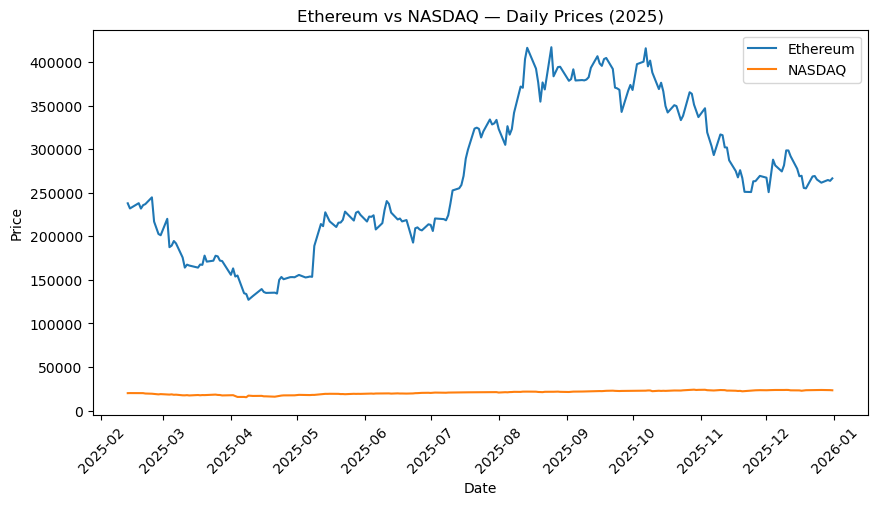

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["date"], df["eth_price"], label="Ethereum")
plt.plot(df["date"], df["nasdaq"], label="NASDAQ")

plt.title("Ethereum vs NASDAQ — Daily Prices (2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [101]:
#4.Find days when oil price spiked and compare with Bitcoin price change.
cursor.execute("""
SELECT *
FROM (
    SELECT 
        o.date,
        o.price_inr AS oil_price,

        ROUND(
            100 * (o.price_inr - LAG(o.price_inr) OVER (ORDER BY o.date))
            / LAG(o.price_inr) OVER (ORDER BY o.date),
            2
        ) AS oil_pct_change,

        b.price_inr AS btc_price,

        ROUND(
            100 * (b.price_inr - LAG(b.price_inr) OVER (ORDER BY b.date))
            / LAG(b.price_inr) OVER (ORDER BY b.date),
            2
        ) AS btc_pct_change

    FROM oil_sy o
    JOIN merged_df b
      ON o.date = b.date
    WHERE b.coin_id = 'bitcoin'
) t
WHERE oil_pct_change >= 5
ORDER BY date
""")

rows = cursor.fetchall()
for r in rows:
    print(r)

(datetime.date(2025, 6, 13), Decimal('6686.950400'), Decimal('7.43'), Decimal('9081227.025134'), Decimal('-2.24'))
(datetime.date(2025, 10, 23), Decimal('5654.566400'), Decimal('5.30'), Decimal('9442499.946296'), Decimal('-1.12'))


In [102]:
#5.Compare top 3 coins daily price trend vs Nifty (^NSEI).
cursor.execute("""
SELECT 
    c.date,
    c.coin_id,
    c.price_inr AS coin_price,
    s.close AS nifty_close
FROM merged_df c
JOIN stocks_df s
  ON c.date = s.date
WHERE c.coin_id IN ('bitcoin','ethereum','tether')
  AND s.ticker = 'NSEI'
ORDER BY c.date
""")

rows = cursor.fetchall()

In [103]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","coin","coin_price","nifty"
])

df.head()

,date,coin,coin_price,nifty
0,2025-02-13,bitcoin,8509967.786199,23031.400391
1,2025-02-13,ethereum,238005.717164,23031.400391
2,2025-02-13,tether,86.984129,23031.400391
3,2025-02-14,bitcoin,8375908.598984,22929.250000
4,2025-02-14,ethereum,232095.151421,22929.250000


In [104]:
df_pivot = df.pivot(
    index="date",
    columns="coin",
    values="coin_price"
)

df_pivot["NSEI"] = df.groupby("date")["nifty"].first()

In [105]:
df_norm = df_pivot / df_pivot.iloc[0]

In [106]:
df_pivot = df.pivot(
    index="date",
    columns="coin",
    values="coin_price"
)

df_pivot["NSEI"] = df.groupby("date")["nifty"].first()

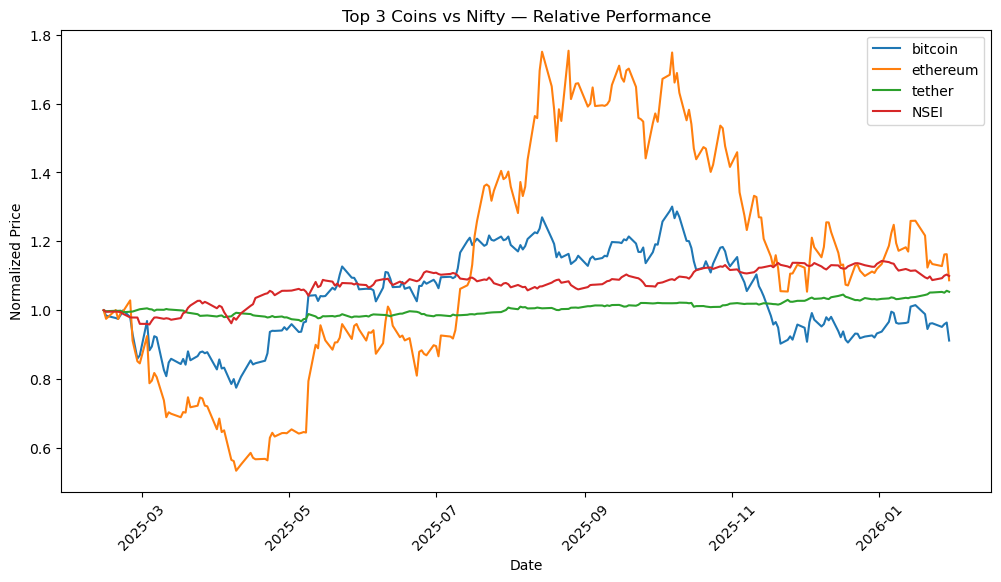

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for col in df_norm.columns:
    plt.plot(df_norm.index, df_norm[col], label=col)

plt.title("Top 3 Coins vs Nifty — Relative Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [108]:
#6.Compare stock prices (^GSPC) with crude oil prices on the same dates
cursor.execute("""
SELECT 
    s.date,
    s.close AS sp500_close,
    o.price_inr AS oil_price
FROM stocks_df s
JOIN oil_sy o
  ON s.date = o.date
WHERE s.ticker = 'GSPC'
ORDER BY s.date
""")

rows = cursor.fetchall()

In [109]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","sp500","oil"
])

df.head()

,date,sp500,oil
0,2021-02-16,3932.590088,5439.939200
1,2021-02-17,3931.330078,5532.310400
2,2021-02-18,3913.969971,5469.824000
3,2021-02-19,3906.709961,5353.907200
4,2021-02-22,3876.500000,5584.835200


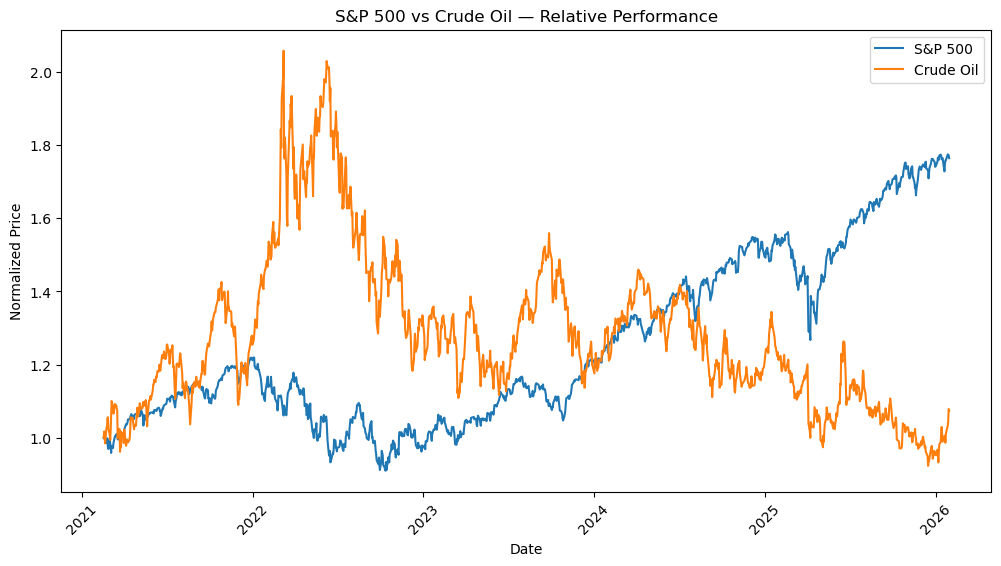

In [110]:
import matplotlib.pyplot as plt

df_norm = df.copy()
df_norm["sp500"] = df_norm["sp500"] / df_norm["sp500"].iloc[0]
df_norm["oil"] = df_norm["oil"] / df_norm["oil"].iloc[0]

plt.figure(figsize=(12,6))

plt.plot(df_norm["date"], df_norm["sp500"], label="S&P 500")
plt.plot(df_norm["date"], df_norm["oil"], label="Crude Oil")

plt.title("S&P 500 vs Crude Oil — Relative Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [112]:
#7.Correlate Bitcoin closing price with crude oil closing price (same date)
cursor.execute("""
SELECT 
    b.date,
    b.price_inr AS btc_price,
    o.price_inr AS oil_price
FROM merged_df b
JOIN oil_sy o
  ON b.date = o.date
WHERE b.coin_id = 'bitcoin'
ORDER BY b.date
""")

rows = cursor.fetchall()

In [113]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","btc_price","oil_price"
])

df.head()

,date,btc_price,oil_price
0,2025-02-13,8509967.786199,6489.529600
1,2025-02-14,8375908.598984,6434.288000
2,2025-02-18,8318633.348144,6539.337600
3,2025-02-19,8297394.500778,6572.844800
4,2025-02-20,8388981.733716,6600.012800


In [114]:
corr = df["btc_price"].corr(df["oil_price"])
print("Price correlation (BTC vs Oil):", corr)

Price correlation (BTC vs Oil): 0.08421703260281263


In [115]:
#8.Compare NASDAQ (^IXIC) with Ethereum price trends
cursor.execute("""
SELECT 
    c.date,
    c.price_inr AS eth_price,
    s.close AS nasdaq_close
FROM merged_df c
JOIN stocks_df s
  ON c.date = s.date
WHERE c.coin_id = 'ethereum'
  AND s.ticker = 'IXIC'
ORDER BY c.date
""")

rows = cursor.fetchall()

In [116]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","eth_price","nasdaq"
])

df.head()

,date,eth_price,nasdaq
0,2025-02-13,238005.717164,19945.640625
1,2025-02-14,232095.151421,20026.769531
2,2025-02-18,238148.028636,20041.259766
3,2025-02-19,231945.569954,20056.250000
4,2025-02-20,235870.263698,19962.359375


In [117]:
df_norm = df.copy()

df_norm["eth_price"] = df_norm["eth_price"] / df_norm["eth_price"].iloc[0]
df_norm["nasdaq"] = df_norm["nasdaq"] / df_norm["nasdaq"].iloc[0]

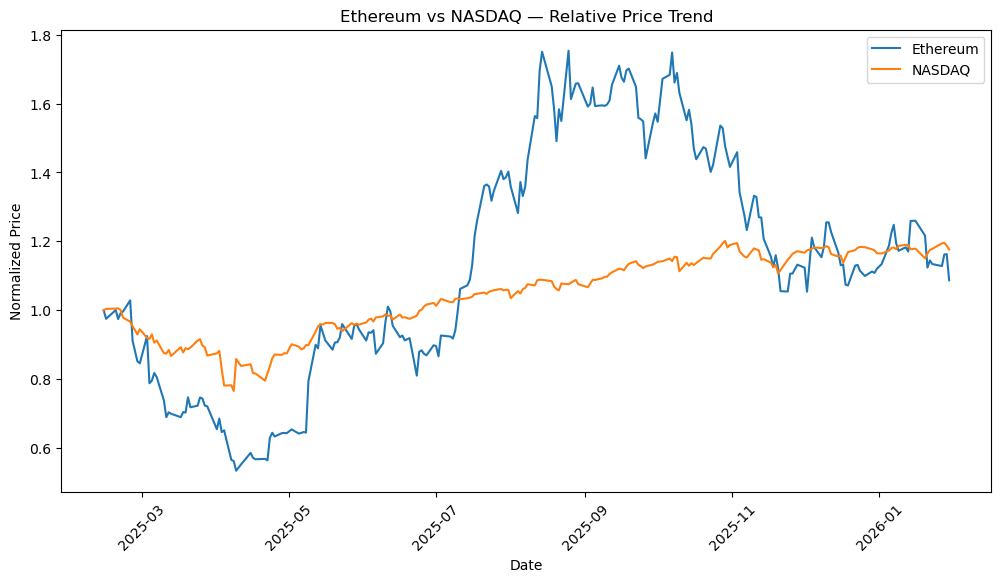

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_norm["date"], df_norm["eth_price"], label="Ethereum")
plt.plot(df_norm["date"], df_norm["nasdaq"], label="NASDAQ")

plt.title("Ethereum vs NASDAQ — Relative Price Trend")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [119]:
#9.Join top 3 crypto coins with stock indices for 2025
cursor.execute("""
SELECT 
    c.date,
    c.coin_id AS asset,
    c.price_inr AS price,
    'crypto' AS asset_type
FROM merged_df c
WHERE c.coin_id IN ('bitcoin','ethereum','tether')
  AND YEAR(c.date) = 2025

UNION ALL

SELECT 
    s.date,
    s.ticker AS asset,
    s.close AS price,
    'stock_index' AS asset_type
FROM stocks_df s
WHERE s.ticker IN ('GSPC','IXIC','NSEI')
  AND YEAR(s.date) = 2025

ORDER BY date, asset;
""")

rows = cursor.fetchall()

In [120]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","asset","price","asset_type"
])

df.head()

,date,asset,price,asset_type
0,2025-01-02,GSPC,5868.549805,stock_index
1,2025-01-02,IXIC,19280.789063,stock_index
2,2025-01-02,NSEI,24188.650391,stock_index
3,2025-01-03,GSPC,5942.470215,stock_index
4,2025-01-03,IXIC,19621.679688,stock_index


In [121]:
#10.Multi-join: stock prices, oil prices, and Bitcoin prices for daily comparison
cursor.execute("""
SELECT 
    s.date,
    s.close AS sp500_close,
    o.price_inr AS oil_price,
    b.price_inr AS btc_price

FROM stocks_df s
JOIN oil_sy o
  ON s.date = o.date
JOIN merged_df b
  ON s.date = b.date

WHERE s.ticker = 'GSPC'
  AND b.coin_id = 'bitcoin'

ORDER BY s.date
""")

rows = cursor.fetchall()

In [123]:
import pandas as pd

df = pd.DataFrame(rows, columns=[
    "date","sp500","oil","bitcoin"
])

df.head()

,date,sp500,oil,bitcoin
0,2025-02-13,6115.069824,6489.529600,8509967.786199
1,2025-02-14,6114.629883,6434.288000,8375908.598984
2,2025-02-18,6129.580078,6539.337600,8318633.348144
3,2025-02-19,6144.149902,6572.844800,8297394.500778
4,2025-02-20,6117.520020,6600.012800,8388981.733716
